In [ ]:
# prefix node reward assignment

let me think               A*=+0.58  ΣA=-0.00 (mean -0.00)  cnt=4  correct=3
  step                       A*=+0.58  ΣA=-0.58 (mean -0.19)  cnt=3  correct=2
    A then 42                  A*=+0.58  ΣA=+0.58 (mean +0.58)  cnt=1  correct=1
    B then                     A*=+0.58  ΣA=-1.15 (mean -0.58)  cnt=2  correct=1
      17                         A*=-1.73  ΣA=-1.73 (mean -1.73)  cnt=1  correct=0
      17, but wait it should be 42 A*=+0.58  ΣA=+0.58 (mean +0.58)  cnt=1  correct=1
  harder C then 9            A*=+0.58  ΣA=+0.58 (mean +0.58)  cnt=1  correct=1


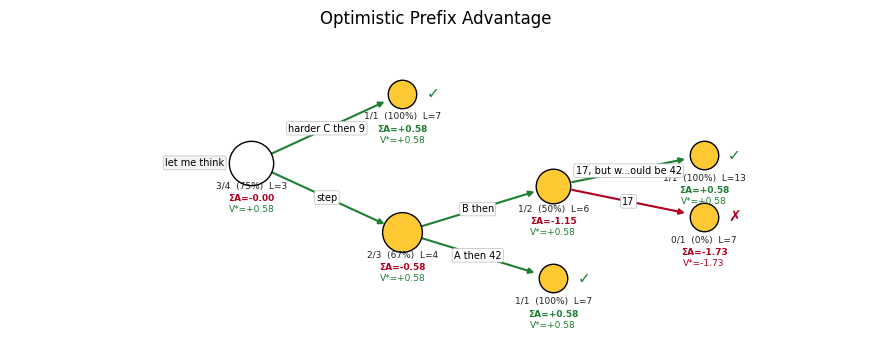

In [1]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("/Users/fangyuanyu/Implementation/arl")))
import src.prefix_trie as pt
importlib.reload(pt)   # pick up changes without restarting the kernel

# ---------------------------------------------------------------------------
# Convention (per request):
#   (1) REWARD is the hard-coded scalar per rollout. Here it's the plain
#       correctness reward, so every CORRECT rollout shares reward = 1.0.
#   (2) ADVANTAGE is computed EXACTLY, GRPO-style, over the group:
#         a_i = (r_i - mean(r)) / (std(r) + eps)
#   (3) V*(node) = max ADVANTAGE over rollouts through the node (optimistic
#       backup over the per-trajectory advantage).
# ---------------------------------------------------------------------------
EPS = 1e-8

rollouts = [
    ("let me think step A then 42".split(),   True),   # correct
    ("let me think step B then 17".split(),   False),  # wrong
    ("let me think step B then 17, but wait it should be 42".split(),   True),  # correct
    ("let me think harder C  then 9".split(), True),  # wrong
]
correct = np.array([c for _, c in rollouts], dtype=float)
reward  = correct.copy()                      # hard-coded reward = correctness

# (1)+(2): exact GRPO advantage over the group.
mean_r = reward.mean()
std_r  = reward.std()                          # population std (ddof=0)
advantage = (reward - mean_r) / (std_r + EPS)  # per-trajectory advantage

tbl = pd.DataFrame({
    "rollout":   [" ".join(t) for t, _ in rollouts],
    "correct":   correct.astype(bool),
    "reward":    reward,
    "advantage": advantage.round(4),
})

# (3): build the trie with the advantage as the per-rollout value.
# `build_trie_with_correctness` feeds `advantage` to BOTH ΣA and V* (= max adv).
rows = [(toks, bool(c), float(a))
        for (toks, c), a in zip(rollouts, advantage)]
trie = pt.build_trie_with_correctness(rows)
tree = pt._collapse(trie.root)

def show(node, depth=0):
    seg = " ".join(node["tokens"]) or "(root)"
    adv_mean = node["adv_sum"] / node["adv_n"] if node["adv_n"] else float("nan")
    print(f"{'  '*depth}{seg:<26s} A*={node['v_star']:+.2f}  "
          f"ΣA={node['adv_sum']:+.2f} (mean {adv_mean:+.2f})  "
          f"cnt={node['count']}  correct={node['count_correct']}")
    for ch in node["children"].values():
        show(ch, depth + 1)

# print("Optimistic Prefix Advantage")
show(tree)


fig, ax = plt.subplots(figsize=(11, 4))
pt.draw_compressed_trie(ax, trie)
ax.set_title("Optimistic Prefix Advantage")
plt.show()


In [2]:
# Now, a trainer inheriting "GRPOTrainer"
#     the trainer builds a per-batch prefix tree, as well as a global prefix tree (somehow I think we'd need it)
#     '_compute_loss' needs to be overwritten with logic above


In [3]:
# --- The OPA core (model-free) ----------------------------------------------
# `optimistic_prefix_advantages` is the per-prefix backup that the trainer uses.
# It does *exactly* what the trie viz above does: A*(prefix) = max a_i over the
# rollouts reachable from that prefix. `return_trie=True` also hands back the
# PrefixTrie so you can inspect a_max at every node.
import src.tree_trainer as tt
importlib.reload(tt)

token_seqs  = [toks for toks, _ in rollouts]          # word-level "tokens"
scalar_advs = advantage.tolist()                       # GRPO group z-scores a_i

per_token, opa_trie = tt.optimistic_prefix_advantages(
    token_seqs, scalar_advs, return_trie=True,
)

for (toks, _), a_i, ptv in zip(rollouts, scalar_advs, per_token):
    print(f"a_i={a_i:+.2f} | " + "  ".join(f"{w}:{v:+.2f}" for w, v in zip(toks, ptv)))

# The lean PrefixTrie only stores a_max (= A*) per node — enough for the
# trainer. For the rich drawing above (success rate, ΣA, ✓/✗ edges) keep using
# `pt.build_trie_with_correctness` + `pt.draw_compressed_trie`, which need the
# correctness counters the trainer doesn't carry.
print(f"\nroot A*={opa_trie.a_max:+.2f}  "
      f"A*['let']={opa_trie.children['let'].a_max:+.2f}")


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

objc[21938]: Class AVFFrameReceiver is implemented in both /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/av/.dylibs/libavdevice.61.1.100.dylib (0x2df5c0798) and /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x30abe83a8). One of the two will be used. Which one is undefined.
objc[21938]: Class AVFAudioReceiver is implemented in both /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/av/.dylibs/libavdevice.61.1.100.dylib (0x2df5c07e8) and /Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x30abe83f8). One of the two will be used. Which one is undefined.


a_i=+0.58 | let:+0.58  me:+0.58  think:+0.58  step:+0.58  A:+0.58  then:+0.58  42:+0.58
a_i=-1.73 | let:+0.58  me:+0.58  think:+0.58  step:+0.58  B:+0.58  then:+0.58  17:-1.73
a_i=+0.58 | let:+0.58  me:+0.58  think:+0.58  step:+0.58  B:+0.58  then:+0.58  17,:+0.58  but:+0.58  wait:+0.58  it:+0.58  should:+0.58  be:+0.58  42:+0.58
a_i=+0.58 | let:+0.58  me:+0.58  think:+0.58  harder:+0.58  C:+0.58  then:+0.58  9:+0.58

root A*=+0.58  A*['let']=+0.58


In [4]:
# === How TreeTrainer._compute_loss works (no model needed) ==================
# In real training TRL hands _compute_loss an `inputs` dict holding token-id
# tensors + the SCALAR GRPO advantage per rollout. TreeTrainer's only job is to
# replace that scalar advantage with the per-token OPA advantage, then call
# super()._compute_loss. The whole rewrite is one staticmethod, so we can drive
# it here with a fake microbatch.
import torch

# --- 1. Fake a GRPO microbatch from the toy rollouts ------------------------
PAD = 0
# Map words -> fake token ids (a shared toy vocabulary).
vocab = {}
def to_ids(words):
    return [vocab.setdefault(w, len(vocab) + 1) for w in words]

seqs = [to_ids(toks) for toks, _ in rollouts]          # one prompt, G=4 generations
G    = len(seqs)
T    = max(len(s) for s in seqs)

prompt_ids     = torch.tensor([[101, 102]] * G)        # same prompt -> one group
completion_ids = torch.full((G, T), PAD, dtype=torch.long)
completion_mask = torch.zeros((G, T), dtype=torch.long)
for i, s in enumerate(seqs):
    completion_ids[i, :len(s)]  = torch.tensor(s)
    completion_mask[i, :len(s)] = 1

adv_scalar = torch.tensor(scalar_advs, dtype=torch.float32)   # TRL's a_i (Bp,)

# --- 2. The exact rewrite _compute_loss performs ----------------------------
adv_token = tt.TreeTrainer._tree_token_advantages(
    prompt_ids, completion_ids, completion_mask, adv_scalar, pad_id=PAD,
)   # (Bp, T) — what gets written back to inputs["advantages"]

# --- 3. Inspect: scalar in -> per-token OPA out -----------------------------
id2w = {v: k for k, v in vocab.items()}
print("scalar advantage a_i (what TRL passes in):")
print("  ", [round(x, 2) for x in adv_scalar.tolist()])
print("\nper-token advantage tensor (what _compute_loss feeds to GRPO):")
for i in range(G):
    m = completion_mask[i].bool()
    toks = [id2w[int(t)] for t in completion_ids[i][m]]
    vals = adv_token[i][m].tolist()
    print(f"  a_i={adv_scalar[i]:+.2f} | "
          + "  ".join(f"{w}:{v:+.2f}" for w, v in zip(toks, vals)))

print(f"\nadv_token.shape = {tuple(adv_token.shape)}  (Bp, T), padding = 0")
# Note: in TreeTrainer.__init__ a real run just does
#   trainer = TreeTrainer(model=..., reward_funcs=[...], args=cfg)
# and the override above runs automatically inside training — no extra wiring.


scalar advantage a_i (what TRL passes in):
   [0.58, -1.73, 0.58, 0.58]

per-token advantage tensor (what _compute_loss feeds to GRPO):
  a_i=+0.58 | let:+0.58  me:+0.58  think:+0.58  step:+0.58  A:+0.58  then:+0.58  42:+0.58
  a_i=-1.73 | let:+0.58  me:+0.58  think:+0.58  step:+0.58  B:+0.58  then:+0.58  17:-1.73
  a_i=+0.58 | let:+0.58  me:+0.58  think:+0.58  step:+0.58  B:+0.58  then:+0.58  17,:+0.58  but:+0.58  wait:+0.58  it:+0.58  should:+0.58  be:+0.58  42:+0.58
  a_i=+0.58 | let:+0.58  me:+0.58  think:+0.58  harder:+0.58  C:+0.58  then:+0.58  9:+0.58

adv_token.shape = (4, 13)  (Bp, T), padding = 0


In [ ]:
# how do we exploit the ""